<a href="https://colab.research.google.com/github/greensky0107/self_study/blob/main/Day51_DeepLearning_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.데이터 로드

Fashion MNIST 데이터셋은 Keras에 내장되어 있으며 fashion_mnist를 임포트하고, load_data()를 호출하여 데이터셋을 로드.

학습용 데이터셋에서 30% 정도를 검증용 데이터셋으로 만들기 위해서 train_test_split() 함수를 이용해 분리.

최종적으로 딥러닝 모델에 사용할 학습, 검증, 테스트 데이터의 갯수를 출력해서 확인

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full,
                                                  test_size=0.3,
                                                  random_state=123)

print(f"전체 학습 데이터: {x_train_full.shape} 레이블: {y_train_full.shape}")
print(f"학습 데이터: {x_train.shape} 레이블: {y_train.shape}")
print(f"검증 데이터: {x_val.shape} 레이블: {y_val.shape}")
print(f"테스트 데이터: {x_test.shape} 레이블: {y_test.shape}")

전체 학습 데이터: (60000, 28, 28) 레이블: (60000,)
학습 데이터: (42000, 28, 28) 레이블: (42000,)
검증 데이터: (18000, 28, 28) 레이블: (18000,)
테스트 데이터: (10000, 28, 28) 레이블: (10000,)


Fashion MNIST 데이터셋에서 사용되는 총 10개의 클래스 이름을 class_names 변수로 지정.

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

train data lable y_train에서 0번째가 무엇인지 출력하면 6이 출력되고, 실제 6이 어떤 클래스인지는 미리 정의한 class_names 리스트에 매칭된 이름으로 Shirt가 출력됨

In [ ]:
print(y_train[0], class_names[y_train[0]])

6 Shirt


학습 데이터 x_train에서 0번째가 어떻게 구성되어 있는지 출력해봄

In [ ]:
print(x_train[0])

[[  0   0   0   1   0   0   0   0  24  69 118 159  70   0   0   0   0  48
  107  68   8   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 145 216 197 186 192 135 194 129 123 183 209
  187 184 207 143   4   0   0   0   0   0]
 [  0   0   0   1   0   0 164 186 119 141 178 198 133 135 211 183 108 194
  216 173 120 197 201   0   0   0   0   0]
 [  0   0   0   3   0  61 174 177   0  71 158 193 226 121 206 174 178 225
  214 182  10 107 175 132   0   0   0   0]
 [  0   0   0   0   0 164 168 168  70 137  76 239 235 199 127 176 238 121
  216 249 190 147 161 214  27   0   0   0]
 [  0   0   0   0 132 174 166 178  73 168  94 131 202 180 196 254  42   0
  152 174 220 176 144 163 139   0   0   0]
 [  0   0   0   6 200 167 162 180  77 173 189 201 219 120 240 124   1 141
  176 193 223 158 143 153 176  56   0   0]
 [  0   0   0   0  85 213 147 188 170 205 218 220 208 143 116  30 181 171
  226 167 233 192 127 153 210 127   0   0]
 [  0   0   0   0   0 149 226 177 211 219 217 179 225 163  64   

학습 데이터는 이미지라서 0~255의 값을 가지고 있고, 이를 이미지로 imshow()를 이용해 출력해봄.   값의 범위를 보기 위해 colorbar()를 이용해 출력.

Could not find 'seaborn-whitegrid', trying 'seaborn' style.
Could not find 'seaborn' style either. Available styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Using 'classic' style as a fallback.


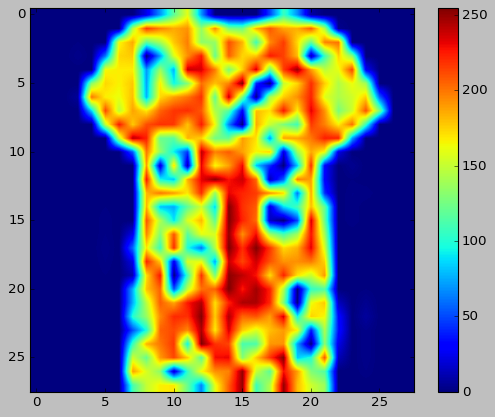

In [ ]:
!pip install seaborn  # Install seaborn library

import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn as well

# Use a valid seaborn-related style.
# Simply importing seaborn often makes its styles available to matplotlib.
# If 'seaborn-whitegrid' still doesn't work, you can try listing available styles
# with print(plt.style.available) to see valid options after importing seaborn.
# For example, 'seaborn' might be a valid style name.
try:
    plt.style.use('seaborn-whitegrid') # Keep trying the user's desired style first
except OSError:
    # If 'seaborn-whitegrid' fails, fall back to a known good seaborn style
    print("Could not find 'seaborn-whitegrid', trying 'seaborn' style.")
    try:
        plt.style.use('seaborn') # Try the general 'seaborn' style
    except OSError:
        # If that also fails, list available styles and pick a default matplotlib one
        print("Could not find 'seaborn' style either. Available styles:")
        print(plt.style.available)
        print("Using 'classic' style as a fallback.")
        plt.style.use('classic') # Fallback to a classic matplotlib style

plt.figure()
plt.imshow(x_train[0])
plt.colorbar()
plt.show()

Fashion MNIST 데이터셋을 확인하기 위해서 전체 학습 데이터 60,000개 중에서 랜덤으로 4개를 선택하여 인덱스와 레이블, 그리고 해당 패션 이미지를 출력해봄.

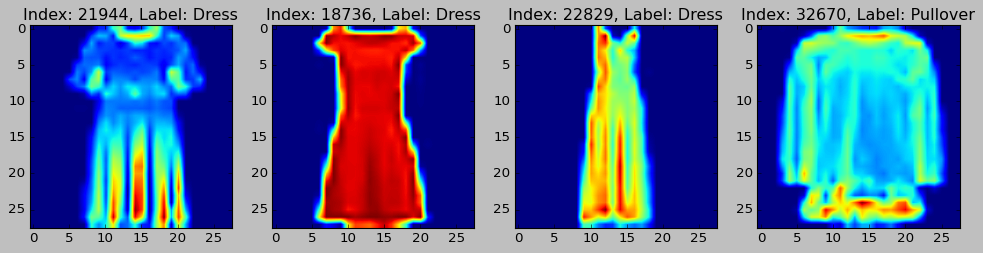

In [ ]:
import numpy as np

num_sample = 4
random_idxs = np.random.randint(60000, size=num_sample)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_idxs):
    image = x_train_full[idx, :]
    label = y_train_full[idx]
    plt.subplot(1, len(random_idxs), i+1)
    plt.imshow(image)
    plt.title(f'Index: {idx}, Label: {class_names[label]}')

# 2.데이터 전처리

딥러닝 모델에서 효과적으로 학습시키기 위해서 입력 데이터를 적절하게 전처리 해주어야함.

데이터셋은 28 x 28 크기의 이미지가 학습 데이터 42,000개, 검증 데이터 18,000개, 테스트 데이터 10,000개로 구성되어 있음.

In [ ]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(42000, 28, 28)
(18000, 28, 28)
(10000, 28, 28)


딥러닝 모델에서 Flatten 레이어를 거쳐도 가능하지만, 미리 데이터셋을 reshape()를 통해 28 * 28 크기인 784로 변형.

여기서는 reshape()을 할 때, 훈련 데이터는 (42000, 784), 검증 데이터는 (18000, 784), 테스트 데이터는 (10000, 784)로 지정해도 되지만, 28 * 28로만 지정하고 나머지는 -1로 지정하여 자동으로 모양을 맞추도록 하였음.

In [ ]:
x_train = x_train.reshape(-1, 28 * 28)
x_val = x_val.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(42000, 784)
(18000, 784)
(10000, 784)


학습 데이터 중에서 0번째 값을 출력해보면, 0부터 255까지의 숫자로 구성되어 있기 때문에 숫자의 범위를 전처리를 통해서 줄여줄 필요가 있음.

In [ ]:
print(x_train[0])

[  0   0   0   1   0   0   0   0  24  69 118 159  70   0   0   0   0  48
 107  68   8   0   0   0   0   0   0   0   0   0   0   0   0   0   0 145
 216 197 186 192 135 194 129 123 183 209 187 184 207 143   4   0   0   0
   0   0   0   0   0   1   0   0 164 186 119 141 178 198 133 135 211 183
 108 194 216 173 120 197 201   0   0   0   0   0   0   0   0   3   0  61
 174 177   0  71 158 193 226 121 206 174 178 225 214 182  10 107 175 132
   0   0   0   0   0   0   0   0   0 164 168 168  70 137  76 239 235 199
 127 176 238 121 216 249 190 147 161 214  27   0   0   0   0   0   0   0
 132 174 166 178  73 168  94 131 202 180 196 254  42   0 152 174 220 176
 144 163 139   0   0   0   0   0   0   6 200 167 162 180  77 173 189 201
 219 120 240 124   1 141 176 193 223 158 143 153 176  56   0   0   0   0
   0   0  85 213 147 188 170 205 218 220 208 143 116  30 181 171 226 167
 233 192 127 153 210 127   0   0   0   0   0   0   0 149 226 177 211 219
 217 179 225 163  64   0 186 152 128 109 216 197 16

기존 데이터셋을 255.0으로 나눠주어 간단하게 0 ~ 255 숫자 범위를 0 ~ 1의 범위로 줄임.

In [ ]:
x_train = x_train / 255.
x_val = x_val / 255.
x_test = x_test / 255.

다시 한번 학습 데이터 0번째 값을 출력하여 0 ~ 1 사이의 숫자로 바뀜을 확인

In [ ]:
print(x_train[0])

[0.         0.         0.         0.00392157 0.         0.
 0.         0.         0.09411765 0.27058824 0.4627451  0.62352941
 0.2745098  0.         0.         0.         0.         0.18823529
 0.41960784 0.26666667 0.03137255 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.56862745
 0.84705882 0.77254902 0.72941176 0.75294118 0.52941176 0.76078431
 0.50588235 0.48235294 0.71764706 0.81960784 0.73333333 0.72156863
 0.81176471 0.56078431 0.01568627 0.         0.         0.
 0.         0.         0.         0.         0.         0.00392157
 0.         0.         0.64313725 0.72941176 0.46666667 0.55294118
 0.69803922 0.77647059 0.52156863 0.52941176 0.82745098 0.71764706
 0.42352941 0.76078431 0.84705882 0.67843137 0.47058824 0.77254902
 0.78823529 0.         0.         0.         0.         0.
 0.         0.         0.         0.01176471 0.         0.23921569
 0.68235294 0.69411765 0.         0

# 3.모델 구성

Fashion MNIST 데이터셋을 패션 종류별로 분류하기 위한 딥러닝 모델을 정의하기 위해 Sequential() 함수를 사용.

첫번째 입력 레이어 Input 으로는 전처리에서 바꾼 모양대로 784개의 형태를 가지도록 하고,

두 번째 레이어는 유닛수 512개와 sigmoid 활성화 함수를 가지는 Dense 레이어를 추가.

그리고 마지막은 분류 갯수인 10으로 유닛수를 지정하고, softmax 활성화 함수를 사용하는 Dense 레이어를 추가.

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Input(shape=(784, )))
model.add(layers.Dense(512, activation='sigmoid'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

# 4.모델 compile 및 학습

모델에 사용할 옵티마이저는 SGD(Stochastic Gradient Descent, 확률적 경사 하강법)를 사용

손실 함수는 다중 분류에 레이블이 정수로 인코딩 되어 있으므로 sparse_categorical_crossentropy를 지정

지표는 accuracy를 사용

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='SGD',
              metrics=['accuracy'])

Fashion MNIST 데이터셋을 학습하기 위해 학습용 데이터셋으로 x_train과 y_train을 지정.

에폭(epochs)은 60으로 지정.

배치 사이즈는 512로 지정.

검증을 위해서는 검증 데이터로 분리시킨 x_val와 y_val를 지정하여 fit() 함수를 실행.

In [ ]:
history = model.fit(x_train, y_train,
                    epochs=60,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2241 - loss: 2.2645 - val_accuracy: 0.4993 - val_loss: 2.0380
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5388 - loss: 1.9754 - val_accuracy: 0.5926 - val_loss: 1.8102
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6175 - loss: 1.7586 - val_accuracy: 0.6532 - val_loss: 1.6323
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6674 - loss: 1.5904 - val_accuracy: 0.6346 - val_loss: 1.4930
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6757 - loss: 1.4556 - val_accuracy: 0.6622 - val_loss: 1.3772
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6925 - loss: 1.3438 - val_accuracy: 0.6626 - val_loss: 1.2818
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6977 - loss: 1.2571 - val_accuracy: 0.7029 - val_loss: 1.2053
Epoch 8/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7108 - loss: 1.1882 - val_accuracy: 0.6934 - val_loss

모델의 학습 과정을 저장한 history에 포함되어 있는 train_loss, val_loss, train_accuracy, val_accuracy를 차트로 시각화하는 show_history() 함수를 정의하고,  실햄후 train vs. validation 비교.

In [ ]:
def show_history(history):
    history_dict = history.history

    loss = history_dict['loss']
    val_loss = history_dict['val_loss']

    epochs = range(1, len(loss) + 1)
    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs, loss, 'b-', label='train_loss')
    ax1.plot(epochs, val_loss, 'r-', label='val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    accuracy = history_dict['accuracy']
    val_accuracy = history_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs, accuracy, 'b-', label='train_accuracy')
    ax2.plot(epochs, val_accuracy, 'r-', label='val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

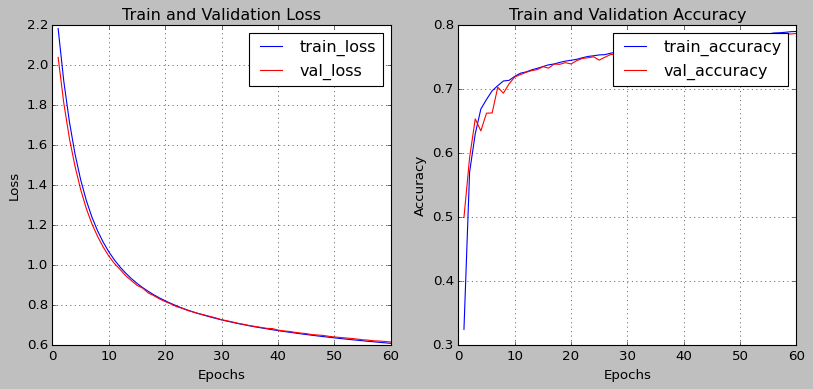

In [ ]:
show_history(history)

# 5.모델 평가및 에측

모델이 학습한 결과를 평가하기 위해서는 테스트 데이터셋인 x_test와 y_test를 지정하여 evaluate()를 실행.

실행 결과로는 모델이 테스트 데이터셋에서는 어느 정도의 성능이 나오는지 loss와 accuracy 값을 확인.

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7844 - loss: 0.6246


[0.6288834810256958, 0.7799000144004822]

학습된 모델을 이용해서 예측을 하기 위해서 predict()를 실행

테스트 데이터 셋인 x_test에 대해 모델의 예측 결과인 pred_ys 중에 5번째를 출력해보면, 분류 10개마다 얼만큼의 비율로 예측했는지 알 수 있음.

분류 10개의 각 값들 중에 가장 큰 값이 있는 위치를 반환하도록 argmax()를 수행한 결과를 arg_pred_y에 저장. 그리고 예시로 5번째를 출력해보면 결과로 1이 나오는 것을 알 수 있음..

인덱스 1에 해당하는 클래스가 무엇인지 class_names 리스트에서 가져오면 Trouser가 출력되는 것을 알 수 있음

In [ ]:
pred_ys = model.predict(x_test)
print(pred_ys[5])

arg_pred_y = np.argmax(pred_ys, axis=1)
print(arg_pred_y[5])
print(class_names[arg_pred_y[5]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.7526057e-02 9.3679386e-01 4.5064990e-03 1.3983289e-02 2.0021850e-02
 4.0861960e-05 6.9894078e-03 3.4703542e-05 8.7038934e-05 1.6328231e-05]
1
Trouser


이미지와 모델이 예측한 결과값을 함께 출력해보면 바지 이미지와 함께 예측한 결과가 출력됨

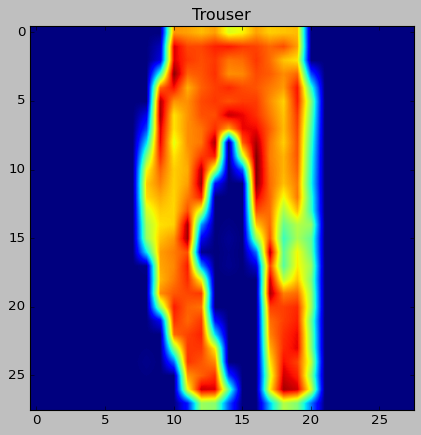

In [ ]:
plt.imshow(x_test[5].reshape(-1, 28))
plt.title(class_names[arg_pred_y[5]])
plt.show()

이미지와 레이블을 함께 출력하기 위해서 plot_image() 함수를 정의

모델이 예측한 값인 pred_ys, 테스트 데이터셋의 정답인 y_test, 그리고 이미지 img에 대해서 i 번째를 가져와서 출력을 수행

여기서 예측한 결과 레이블인 predicted_label과 정답 레이블인 y_test가 동일하면 색으로 blue를 사용하고, 다르면 red 색을 사용하도록 지정.

이제 예측한 레이블의 이름, 예측한 확률값, 실제 정답 레이블의 이름을 지정한 색으로 출력

In [ ]:
def plot_image(i, pred_ys, y_test, img):
    pred_ys, y_test, img = pred_ys[i], y_test[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(pred_ys)
    if predicted_label == y_test:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                       100*np.max(pred_ys),
                                       class_names[y_test]), color=color)

전체 10개 분류 중에서 어떤 클래스에 얼만큼의 확률로 예측을 했는지 출력해주는 plot_class() 함수를 정의.

예측한 결과 레이블인 pred_ys와 정답 레이블인 true_label에서 i 번째의 데이터에 대한 10개 클래스 값들을 바 차트로 시각화.

기본적으로는 색을 darkgray로 지정하고, 예측한 레이블은 red 색상으로 표시하고, 정답 레이블은 blue 색상으로 표시.

In [ ]:
def plot_class(i, pred_ys, true_label):
    pred_ys, true_label = pred_ys[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.ylim([0, 1])
    predicted_label = np.argmax(pred_ys)

    plot = plt.bar(range(10), pred_ys, color='darkgray')
    plot[predicted_label].set_color('red')
    plot[true_label].set_color('blue')

5번째 데이터에 대해서 정의한 plot_image()와 plot_class() 함수를 호출하여 시각화해보면, 모델이 Trouser라고 93% 확률로 예측함을 확인.

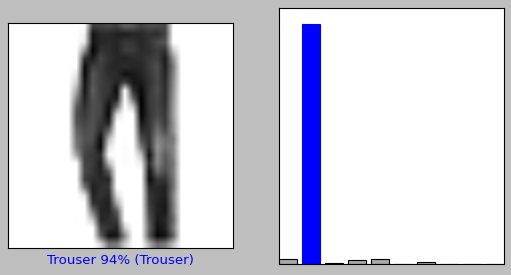

In [ ]:
i = 5
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(i, pred_ys, y_test, x_test.reshape(-1, 28, 28))
plt.subplot(1, 2, 2)
plot_class(i, pred_ys, y_test)
plt.show()

10번째 데이터에 대해서도 마찬가지로 출력해보면, 모델은 Pullover로 예측을 했지만, 실제 정답은 Coat로 오차가 있음을 알 수 있음

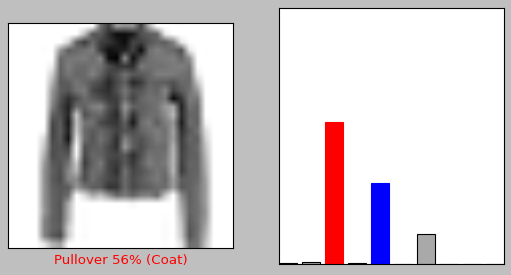

In [ ]:
i = 10
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(i, pred_ys, y_test, x_test.reshape(-1, 28, 28))
plt.subplot(1, 2, 2)
plot_class(i, pred_ys, y_test)
plt.show()

이제 모델 예측 결과 여러 개를 눈으로 확인할 수 있도록 32(8x4)개를 출력

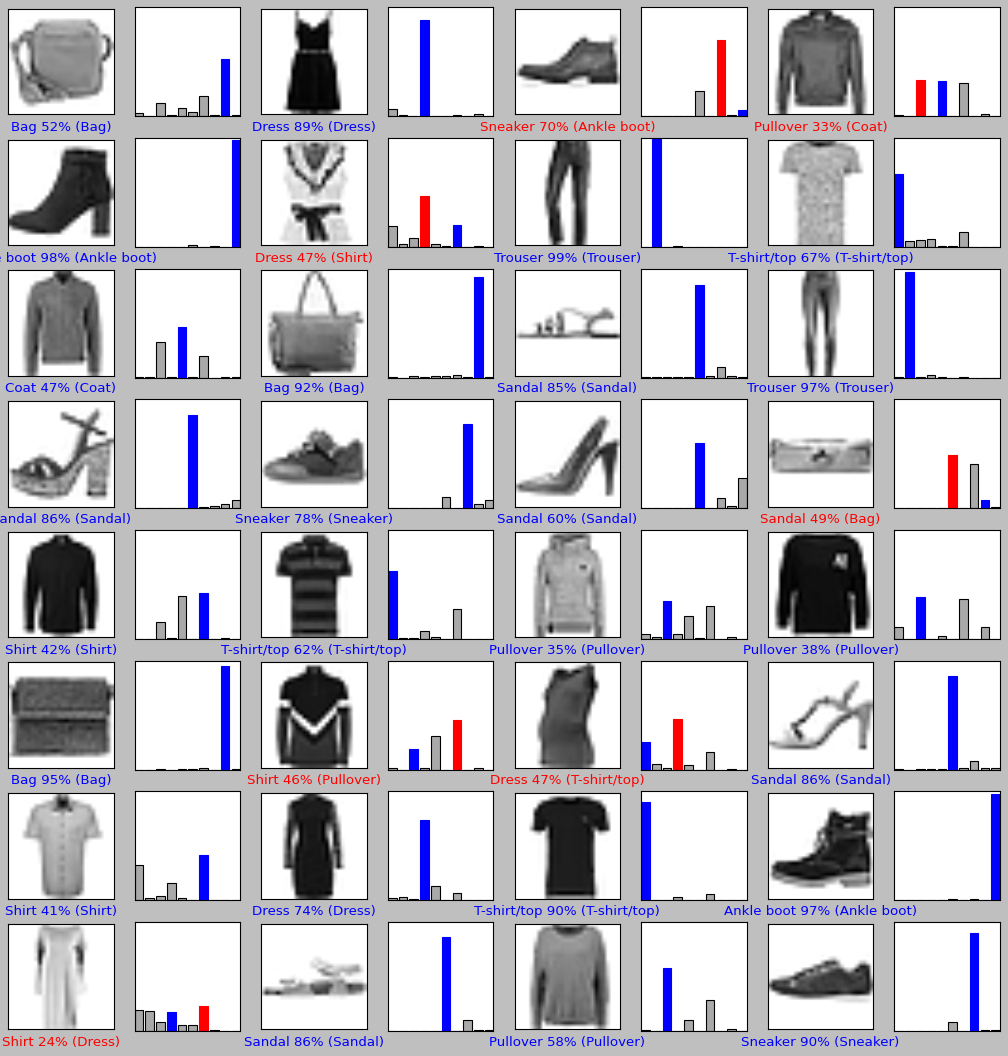

In [ ]:
num_rows = 8
num_cols = 4
num_images = num_rows * num_cols

random_num = np.random.randint(10000, size=num_images)
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for idx, num in enumerate(random_num):
    plt.subplot(num_rows, 2 * num_cols, 2 * idx + 1)
    plot_image(num, pred_ys, y_test, x_test.reshape(-1, 28, 28))
    plt.subplot(num_rows, 2 * num_cols, 2 * idx + 2)
    plot_class(num, pred_ys, y_test)

plt.show()

classification_report를 이용하여 Fashion MNIST를 분류하는 모델의 결과를 10개 분류 기준 별로 precision, recall, f1-score, support를 확인

In [ ]:
from tensorflow.keras import utils
from sklearn.metrics import classification_report

y_test_cat = utils.to_categorical(y_test)
print(classification_report(np.argmax(y_test_cat, axis=-1),
                            np.argmax(pred_ys, axis=-1),
                            target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.78      0.77      1000
     Trouser       0.97      0.92      0.94      1000
    Pullover       0.66      0.66      0.66      1000
       Dress       0.77      0.84      0.80      1000
        Coat       0.67      0.64      0.66      1000
      Sandal       0.85      0.83      0.84      1000
       Shirt       0.49      0.46      0.47      1000
     Sneaker       0.84      0.85      0.85      1000
         Bag       0.92      0.91      0.91      1000
  Ankle boot       0.88      0.91      0.89      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



confusion_matrix를 이용해서 예측한 레이블과 실제 레이블과의 일치 여부를 혼동 행렬(confusion matrix)로 시각화해봄

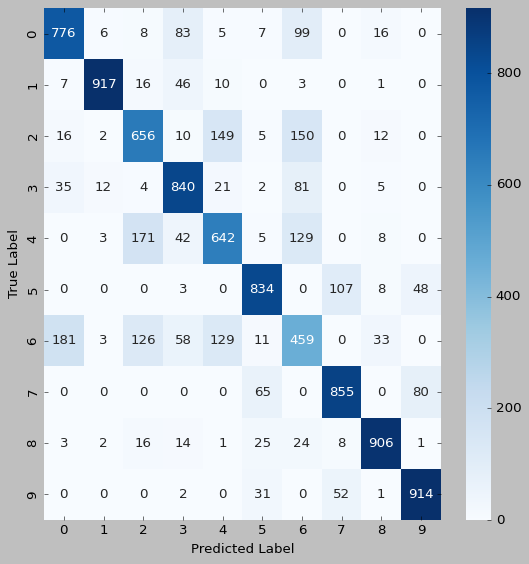

In [ ]:
# 6번 shirt가 가장 혼동되었으며, 0번 t-shirts/top과 가장 많이 혼동함

import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 8))
cm2 = confusion_matrix(np.argmax(y_test_cat, axis=-1), np.argmax(pred_ys, axis=-1))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6.최적화 방법 - Early Stopping

Fashion MNIST에 모델 성능을 높일 수 있는 최적화 방법을 수행.

최적화 방법은 빠른 학습과 과대 적합을 방지.

최적화 방법을 적용한 모델과 적용하지 않은 모델의 결과를 비교.

Early Stopping  (학습 과정을 최적화)

딥러닝 모델이 학습을 진행하면서 가장 좋은 모델이 fashion_mnist_model.h5 파일로 저장되도록 콜백 함수로 ModelCheckpoint를 사용.

또한 val_loss 값을 10개씩 연속으로 모니터링하며 성능 변화가 없으면 조기 종료되도록 EarlyStopping을 사용.

정의한 콜백 함수를 사용하여 fit() 함수를 실행하여 실제 모델 학습을 진행.

In [ ]:
from tensorflow.keras import callbacks

check_point_cb = callbacks.ModelCheckpoint('fashion_mnist_model.h5',
                                           save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=10,
                                            monitor='val_loss',
                                            restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=60,
                    validation_data=(x_val, y_val),
                    callbacks=[check_point_cb, early_stopping_cb])

KeyboardInterrupt: 

모델의 학습 히스토리 시각화 와 모델의 평가 결과를 테스트 데이터셋을 이용해 확인

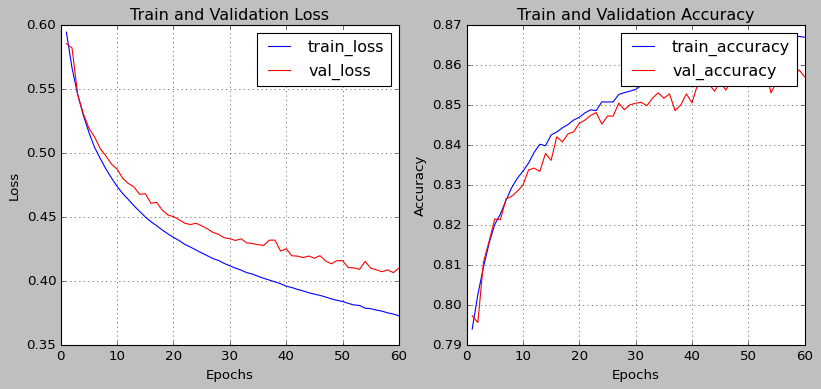

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8496 - loss: 0.4208


[0.4265383780002594, 0.8431000113487244]

In [ ]:
show_history(history)
model.evaluate(x_test, y_test)

# 7.최적화 방법 - 활성화 함수를 relu로 변경

Fashion MNIST 데이터셋을 패션 종류별로 분류하기 위한 딥러닝 모델을 정의하기 위해 Sequential() 함수를 사용.

첫번째 입력 레이어 Input 으로는 전처리에서 바꾼 모양대로 784개의 형태를 가지도록 하고,

두 번째 레이어는 유닛수 512개와 비선형 함수인 relu를 활성화 함수로 가지는 Dense 레이어를 추가.

그리고 마지막은 분류 갯수인 10으로 유닛수를 지정하고, softmax 활성화 함수를 사용하는 Dense 레이어를 추가.

(기존 Model과 다른 점은 활성화 함수로 선형 함수인 sigmoid를 사용하였는데, 비선형 함수인 relu로 변경)

In [ ]:
from tensorflow.keras import models, layers

relu_model = models.Sequential()
relu_model.add(layers.Input(shape=(784, )))
relu_model.add(layers.Dense(512, activation='relu'))
relu_model.add(layers.Dense(10, activation='softmax'))
relu_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
relu_model.compile(loss='sparse_categorical_crossentropy',
              optimizer='SGD',
              metrics=['accuracy'])

In [ ]:
history2 = relu_model.fit(x_train, y_train, epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6725 - loss: 1.0531 - val_accuracy: 0.8114 - val_loss: 0.5838
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8183 - loss: 0.5463 - val_accuracy: 0.8326 - val_loss: 0.5044
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8342 - loss: 0.4863 - val_accuracy: 0.8270 - val_loss: 0.4961
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8423 - loss: 0.4551 - val_accuracy: 0.8463 - val_loss: 0.4612
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8514 - loss: 0.4311 - val_accuracy: 0.8477 - val_loss: 0.4461
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8559 - loss: 0.4175 - val_accuracy: 0.8538 - val_loss: 0.4303
Epoch 7/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8570 - loss: 0.4079 - val_accuracy: 0.8571 - val_loss: 0.4203
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8653 - loss: 0.3919 -

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8741 - loss: 0.3554 - val_accuracy: 0.8652 - val_loss: 0.3931
Epoch 14/60
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - loss: 0.3529

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8768 - loss: 0.3529 - val_accuracy: 0.8684 - val_loss: 0.3818
Epoch 15/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8796 - loss: 0.3469 - val_accuracy: 0.8629 - val_loss: 0.3901
Epoch 16/60
1293/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8791 - loss: 0.3431

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8791 - loss: 0.3431 - val_accuracy: 0.8711 - val_loss: 0.3735
Epoch 17/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8832 - loss: 0.3310 - val_accuracy: 0.8685 - val_loss: 0.3773
Epoch 18/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8857 - loss: 0.3319 - val_accuracy: 0.8718 - val_loss: 0.3776
Epoch 19/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8850 - loss: 0.3278 - val_accuracy: 0.8637 - val_loss: 0.3861
Epoch 20/60
1298/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8873 - loss: 0.3194

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8873 - loss: 0.3194 - val_accuracy: 0.8752 - val_loss: 0.3623
Epoch 21/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8866 - loss: 0.3196 - val_accuracy: 0.8738 - val_loss: 0.3643
Epoch 22/60
1293/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8902 - loss: 0.3143

...

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9088 - loss: 0.2597 - val_accuracy: 0.8845 - val_loss: 0.3308
Epoch 42/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9096 - loss: 0.2594 - val_accuracy: 0.8824 - val_loss: 0.3363
Epoch 43/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9126 - loss: 0.2479 - val_accuracy: 0.8787 - val_loss: 0.3466
Epoch 44/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9151 - loss: 0.2453 - val_accuracy: 0.8801 - val_loss: 0.3413
Epoch 45/60
1309/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9149 - loss: 0.2435

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9149 - loss: 0.2435 - val_accuracy: 0.8852 - val_loss: 0.3282
Epoch 46/60
1294/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9165 - loss: 0.2389

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9165 - loss: 0.2390 - val_accuracy: 0.8877 - val_loss: 0.3253
Epoch 47/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9147 - loss: 0.2405 - val_accuracy: 0.8840 - val_loss: 0.3295
Epoch 48/60
1298/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9189 - loss: 0.2393

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9189 - loss: 0.2393 - val_accuracy: 0.8894 - val_loss: 0.3217
Epoch 49/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9145 - loss: 0.2385 - val_accuracy: 0.8859 - val_loss: 0.3244
Epoch 50/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9176 - loss: 0.2344 - val_accuracy: 0.8783 - val_loss: 0.3440
Epoch 51/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9184 - loss: 0.2298 - val_accuracy: 0.8835 - val_loss: 0.3349
Epoch 52/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9218 - loss: 0.2261 - val_accuracy: 0.8856 - val_loss: 0.3242
Epoch 53/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9191 - loss: 0.2308 - val_accuracy: 0.8896 - val_loss: 0.3218
Epoch 54/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9217 - loss: 0.2286 - val_accuracy: 0.8891 - val_loss: 0.3257
Epoch 55/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9217 - loss: 0.2230 - val_

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9232 - loss: 0.2184 - val_accuracy: 0.8891 - val_loss: 0.3162
Epoch 59/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9250 - loss: 0.2160 - val_accuracy: 0.8841 - val_loss: 0.3332
Epoch 60/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9284 - loss: 0.2085 - val_accuracy: 0.8857 - val_loss: 0.3305


두 개의 모델 학습 히스토리를 차트로 비교할 수 있도록 시각화하는 diff_history() 함수를 정의.






In [ ]:
def diff_history(history1, history2):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history2_dict = history2.history
    h2_loss = history2_dict['loss']
    h2_val_loss = history2_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs2 = range(1, len(h2_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs2, h2_loss, 'b--', label='h2_train_loss')
    ax1.plot(epochs2, h2_val_loss, 'r--', label='h2_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h2_accuracy = history2_dict['accuracy']
    h2_val_accuracy = history2_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs2, h2_accuracy, 'b--', label='h2_train_accuracy')
    ax2.plot(epochs2, h2_val_accuracy, 'r--', label='h2_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

기존 모델과 활성화 함수를 relu로 변경한 모델의 학습 결과를 시각화하고, 활성화 함수를 변경한 모델의 평가 결과를 확인.

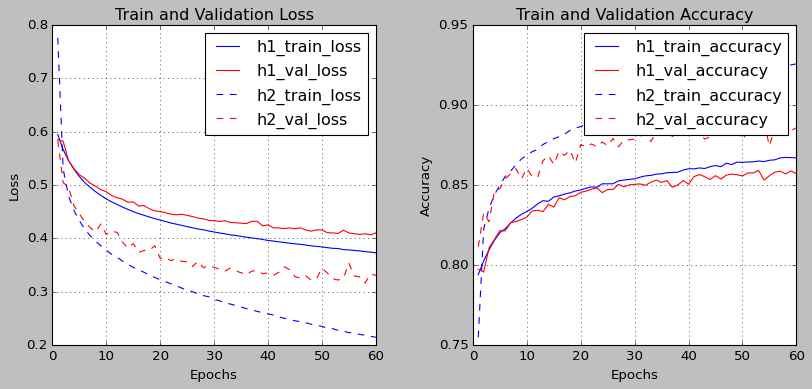

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1941 - loss: 2.4097


[2.410595417022705, 0.19050000607967377]

In [ ]:
diff_history(history, history2)
relu_model.compile(loss='sparse_categorical_crossentropy',
              optimizer='SGD',
              metrics=['accuracy'])
relu_model.evaluate(x_test, y_test)

# 8.최적화 방법 - Optimizer Adam으로 변경

기존 모델에서는 옵티마이저로 SGD를 사용했는데, 좀 더 빠르고 효과적인 학습이 가능하도록 Adam으로 변경.

활성함수는 relu로 변경

In [ ]:
from tensorflow.keras import models, layers

model3 = models.Sequential()
model3.add(layers.Input(shape=(784, )))
model3.add(layers.Dense(512, activation='relu'))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [ ]:
history3 = model3.fit(x_train, y_train, epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7815 - loss: 0.6228 - val_accuracy: 0.8443 - val_loss: 0.4440
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8614 - loss: 0.3811 - val_accuracy: 0.8618 - val_loss: 0.3849
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8744 - loss: 0.3343 - val_accuracy: 0.8720 - val_loss: 0.3624
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8860 - loss: 0.3024 - val_accuracy: 0.8551 - val_loss: 0.4153
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8927 - loss: 0.2877 - val_accuracy: 0.8762 - val_loss: 0.3435
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8991 - loss: 0.2698 - val_accuracy: 0.8803 - val_loss: 0.3401
Epoch 7/60
1302/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9018 - loss: 0.2607

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9018 - loss: 0.2607 - val_accuracy: 0.8904 - val_loss: 0.3140
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9078 - loss: 0.2444 - val_accuracy: 0.8845 - val_loss: 0.3352
Epoch 9/60
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9122 - loss: 0.2378

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9122 - loss: 0.2378 - val_accuracy: 0.8940 - val_loss: 0.3073
Epoch 10/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9150 - loss: 0.2240 - val_accuracy: 0.8846 - val_loss: 0.3397
Epoch 11/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9193 - loss: 0.2123 - val_accuracy: 0.8847 - val_loss: 0.3371
Epoch 12/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9196 - loss: 0.2109 - val_accuracy: 0.8861 - val_loss: 0.3391
Epoch 13/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9237 - loss: 0.2014 - val_accuracy: 0.8938 - val_loss: 0.3196
Epoch 14/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9286 - loss: 0.1933 - val_accuracy: 0.8888 - val_loss: 0.3396
Epoch 15/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9326 - loss: 0.1806 - val_accuracy: 0.8922 - val_loss: 0.3411
Epoch 16/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9334 - loss: 0.1785 - val_

기존 모델 학습 결과와 옵티마이저를 바꾼 모델의 학습 결과를 살펴보면, 학습이 빠르게 진행되어 조기에 종료되는 것을 알 수 있음. 다만, 과대적합이 발생.

In [ ]:
def diff_history(history1, history3):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history3_dict = history3.history
    h3_loss = history3_dict['loss']
    h3_val_loss = history3_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs3 = range(1, len(h3_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs3, h3_loss, 'b--', label='h3_train_loss')
    ax1.plot(epochs3, h3_val_loss, 'r--', label='h3_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h3_accuracy = history3_dict['accuracy']
    h3_val_accuracy = history3_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs3, h3_accuracy, 'b--', label='h3_train_accuracy')
    ax2.plot(epochs3, h3_val_accuracy, 'r--', label='h3_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

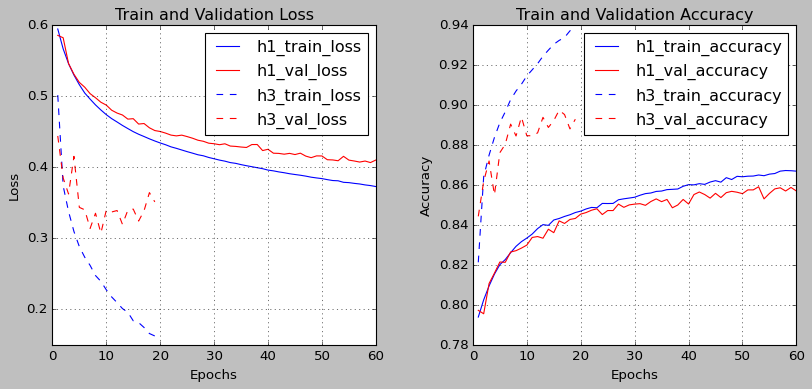

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8868 - loss: 0.3219


[0.32555896043777466, 0.8866999745368958]

In [ ]:
# Make sure the cells that define and assign values to 'history' and 'history3'
# are executed before this cell.
diff_history(history, history3)
model3.evaluate(x_test, y_test)

# 9.촤적화 방법 - 규제 Dense layer에  L2 적용

모델에서 과대적합이 발생하는 부분을 규제하기 위해서 중간의 Dense 레이어에 L2 규제 방법을 적용

In [ ]:
from tensorflow.keras import models, layers

model4 =  models.Sequential()
model4.add(layers.Input(shape=(784, )))
model4.add(layers.Dense(512,
                          kernel_regularizer='l2',
                          activation='relu'))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model4.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [ ]:
history4 = model4.fit(x_train, y_train,
                     epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7439 - loss: 1.9302 - val_accuracy: 0.7298 - val_loss: 0.8822
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7928 - loss: 0.7318 - val_accuracy: 0.8095 - val_loss: 0.6884
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8038 - loss: 0.6888 - val_accuracy: 0.8057 - val_loss: 0.7076
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8069 - loss: 0.6656 - val_accuracy: 0.8152 - val_loss: 0.6384
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8174 - loss: 0.6300 - val_accuracy: 0.8239 - val_loss: 0.6467
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8268 - loss: 0.6061 - val_accuracy: 0.8138 - val_loss: 0.6332
Epoch 7/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8277 - loss: 0.5988 - val_accuracy: 0.8153 - val_loss: 0.6192
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8314 - loss: 0.5873 - 

기존 모델 학습 결과와 L2 규제 방법을 적용한 모델의 학습 결과를 비교해보면, 성능은 일부 저하되지만 어느정도 과대적합을 억제됨을 알 수 있음.

In [ ]:
def diff_history(history1, history4):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history4_dict = history4.history
    h4_loss = history4_dict['loss']
    h4_val_loss = history4_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs4 = range(1, len(h4_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs4, h4_loss, 'b--', label='h4_train_loss')
    ax1.plot(epochs4, h4_val_loss, 'r--', label='h4_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h4_accuracy = history4_dict['accuracy']
    h4_val_accuracy = history4_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs4, h4_accuracy, 'b--', label='h4_train_accuracy')
    ax2.plot(epochs4, h4_val_accuracy, 'r--', label='h4_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

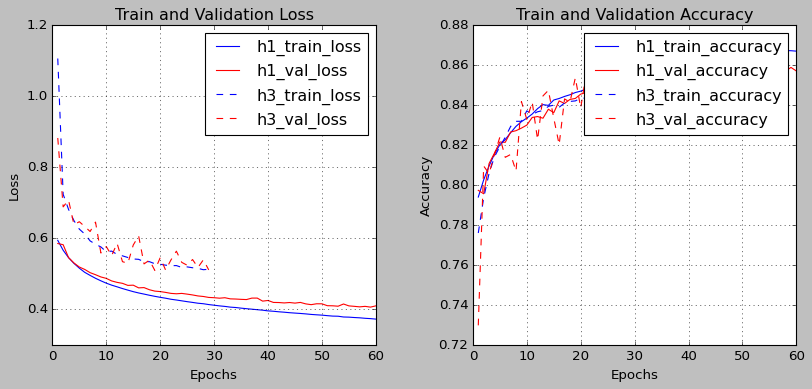

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.5177


[0.5244979858398438, 0.8439000248908997]

In [ ]:
diff_history(history, history4)
model4.evaluate(x_test, y_test)

# 9.최적화 방법 : Dropout

모델에서 성능 저하를 최소화하면서 과대적합을 억제하기 위한 방법으로 Dense 레이어 사이에 50%의 Dropout 레이어 적용

In [ ]:
from tensorflow.keras import models, layers

model5 =  models.Sequential()
model5.add(layers.Input(shape=(784, )))
model5.add(layers.Dense(512,
                          kernel_regularizer='l2',
                          activation='relu'))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(10, activation='softmax'))
model5.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model5.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [ ]:
history5 = model5.fit(x_train, y_train,
                     epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7053 - loss: 2.1540 - val_accuracy: 0.7971 - val_loss: 0.7845
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7583 - loss: 0.8671 - val_accuracy: 0.7959 - val_loss: 0.7579
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7658 - loss: 0.8371 - val_accuracy: 0.8073 - val_loss: 0.7406
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7671 - loss: 0.8196 - val_accuracy: 0.7968 - val_loss: 0.7497
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7699 - loss: 0.8117 - val_accuracy: 0.8033 - val_loss: 0.7224
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7701 - loss: 0.7953 - val_accuracy: 0.8147 - val_loss: 0.6941
Epoch 7/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7707 - loss: 0.7967 - val_accuracy: 0.8125 - val_loss: 0.7036
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7756 - loss: 0.7715 - 

기존 모델 학습 결과와 드롭아웃을 적용한 방법의 학습 결과를 살펴보면, 과대적합을 잘 방지하고 있음

In [ ]:
def diff_history(history1, history5):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history5_dict = history5.history
    h5_loss = history5_dict['loss']
    h5_val_loss = history5_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs5 = range(1, len(h5_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs5, h5_loss, 'b--', label='h5_train_loss')
    ax1.plot(epochs5, h5_val_loss, 'r--', label='h5_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h5_accuracy = history5_dict['accuracy']
    h5_val_accuracy = history5_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs5, h5_accuracy, 'b--', label='h5_train_accuracy')
    ax2.plot(epochs5, h5_val_accuracy, 'r--', label='h5_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

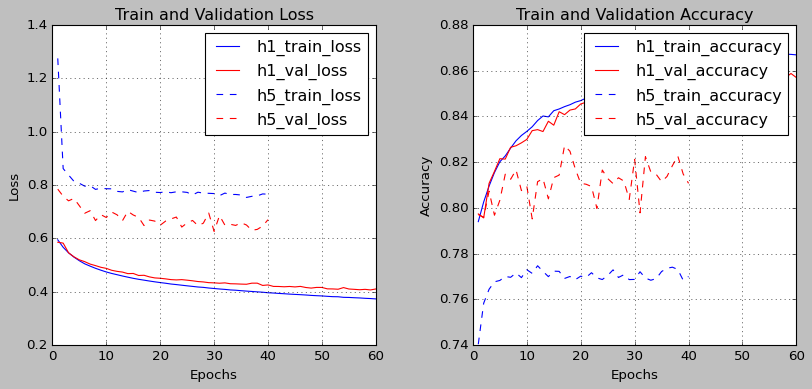

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8146 - loss: 0.6444


[0.6454790234565735, 0.8101999759674072]

In [ ]:
diff_history(history, history5)
model5.evaluate(x_test, y_test)

 L2 규제와 Dropout 비교시 Dropout 이 더 좋은 결과를 보여줌.

In [ ]:
def diff_history(history4, history5):
    history4_dict = history4.history
    h4_loss = history4_dict['loss']
    h4_val_loss = history4_dict['val_loss']

    history5_dict = history5.history
    h5_loss = history5_dict['loss']
    h5_val_loss = history5_dict['val_loss']

    epochs4 = range(1, len(h4_loss) + 1)
    epochs5 = range(1, len(h5_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs4, h4_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs4, h4_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs5, h5_loss, 'b--', label='h5_train_loss')
    ax1.plot(epochs5, h5_val_loss, 'r--', label='h5_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h4_accuracy = history4_dict['accuracy']
    h4_val_accuracy = history4_dict['val_accuracy']

    h5_accuracy = history5_dict['accuracy']
    h5_val_accuracy = history5_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs4, h4_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs4, h4_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs5, h5_accuracy, 'b--', label='h5_train_accuracy')
    ax2.plot(epochs5, h5_val_accuracy, 'r--', label='h5_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

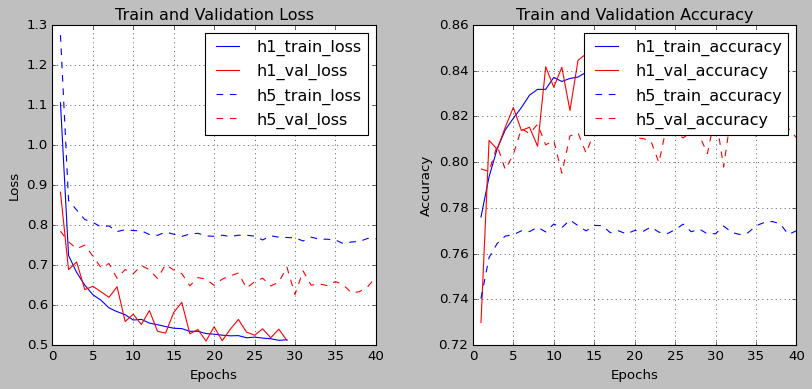

In [ ]:
diff_history(history4, history5)

# 10.최적화 방법 : Batch Normalization

빠르고 효과적인 학습을 도와주는 배치 정규화도 적용해보기 위해 Dense 레이어 다음에 BatchNormalization 레이어를 추가하고, 이후 활성화 함수 Activation 레이어를 추가.

In [ ]:
from tensorflow.keras import models, layers

model5 =  models.Sequential()
model5.add(layers.Input(shape=(784, )))
model5.add(layers.Dense(512,
                          kernel_regularizer='l2',
                          activation='relu'))
model5.add(layers.BatchNormalization())
model5.add(layers.Activation('relu'))
model5.add(layers.Dense(10, activation='softmax'))
model5.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,098 (1.56 MB)

 Trainable params: 408,074 (1.56 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
model5.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [ ]:
history6 = model5.fit(x_train, y_train,
                     epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7893 - loss: 2.3131 - val_accuracy: 0.6163 - val_loss: 1.5282
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8117 - loss: 0.7374 - val_accuracy: 0.4353 - val_loss: 2.7688
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8173 - loss: 0.7045 - val_accuracy: 0.7405 - val_loss: 0.9502
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8214 - loss: 0.6898 - val_accuracy: 0.7802 - val_loss: 0.8215
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8255 - loss: 0.6446 - val_accuracy: 0.7772 - val_loss: 0.8319
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8315 - loss: 0.6269 - val_accuracy: 0.7282 - val_loss: 0.9373
Epoch 7/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8317 - loss: 0.6094 - val_accuracy: 0.7797 - val_loss: 0.8411
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8354 - loss: 0.5993 

In [ ]:
def diff_history(history1, history6):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history6_dict = history6.history
    h6_loss = history6_dict['loss']
    h6_val_loss = history6_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs6 = range(1, len(h6_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs6, h6_loss, 'b--', label='h6_train_loss')
    ax1.plot(epochs6, h6_val_loss, 'r--', label='h6_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h6_accuracy = history6_dict['accuracy']
    h6_val_accuracy = history6_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs6, h6_accuracy, 'b--', label='h6_train_accuracy')
    ax2.plot(epochs6, h6_val_accuracy, 'r--', label='h6_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

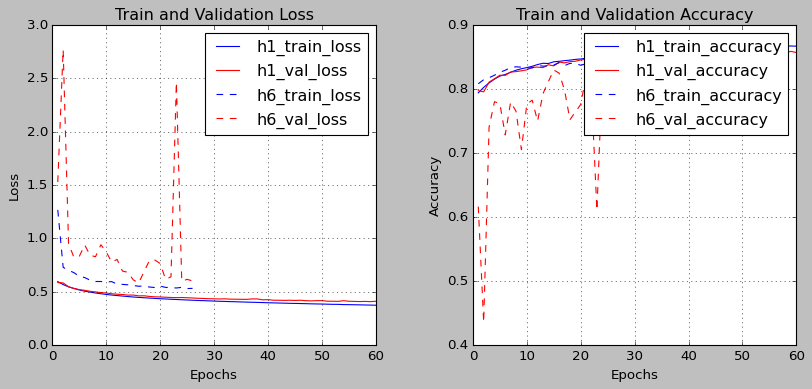

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.5908


[0.600095808506012, 0.8220999836921692]

In [ ]:
diff_history(history, history6)
model5.evaluate(x_test, y_test)

# 11.최적화 방법 ;  Batch Normalization + Dropout

배치 정규화를 통해 안정적인 학습이 가능하지만, 규제 방법 중 좋은 성능을 보였던 드롭아웃을 함께 적용해서 성능 향상되는 지 봄.
기존 배치 정규화를 적용한 모델에 Activation 레이어 이후에 Dropout 레이어를 추가.

In [ ]:
from tensorflow.keras import models, layers

model7 =  models.Sequential()
model7.add(layers.Input(shape=(784, )))
model7.add(layers.Dense(512,
                          kernel_regularizer='l2',
                          activation='relu'))
model7.add(layers.BatchNormalization())
model7.add(layers.Activation('relu'))
model7.add(layers.Dropout(0.2))
model7.add(layers.Dense(10, activation='softmax'))
model7.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,098 (1.56 MB)

 Trainable params: 408,074 (1.56 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
model7.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [ ]:
history7 = model7.fit(x_train, y_train,
                     epochs=60,
                     validation_data=(x_val, y_val),
                     callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7802 - loss: 2.3660 - val_accuracy: 0.6234 - val_loss: 1.4298
Epoch 2/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7998 - loss: 0.8041 - val_accuracy: 0.7871 - val_loss: 0.7983
Epoch 3/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7926 - loss: 0.7921 - val_accuracy: 0.7316 - val_loss: 1.0411
Epoch 4/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8036 - loss: 0.7605 - val_accuracy: 0.7488 - val_loss: 0.9120
Epoch 5/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8004 - loss: 0.7491 - val_accuracy: 0.7764 - val_loss: 0.8569
Epoch 6/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8011 - loss: 0.7508 - val_accuracy: 0.7167 - val_loss: 0.9838
Epoch 7/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7997 - loss: 0.7560 - val_accuracy: 0.7131 - val_loss: 1.2649
Epoch 8/60
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8058 - loss: 0.7251 -

In [ ]:
def diff_history(history1, history7):
    history1_dict = history1.history
    h1_loss = history1_dict['loss']
    h1_val_loss = history1_dict['val_loss']

    history7_dict = history7.history
    h7_loss = history7_dict['loss']
    h7_val_loss = history7_dict['val_loss']

    epochs1 = range(1, len(h1_loss) + 1)
    epochs7 = range(1, len(h7_loss) + 1)

    fig = plt.figure(figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(epochs1, h1_loss, 'b-', label='h1_train_loss')
    ax1.plot(epochs1, h1_val_loss, 'r-', label='h1_val_loss')
    ax1.plot(epochs7, h7_loss, 'b--', label='h7_train_loss')
    ax1.plot(epochs7, h7_val_loss, 'r--', label='h7_val_loss')
    ax1.set_title('Train and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid()
    ax1.legend()

    h1_accuracy = history1_dict['accuracy']
    h1_val_accuracy = history1_dict['val_accuracy']

    h7_accuracy = history7_dict['accuracy']
    h7_val_accuracy = history7_dict['val_accuracy']

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(epochs1, h1_accuracy, 'b-', label='h1_train_accuracy')
    ax2.plot(epochs1, h1_val_accuracy, 'r-', label='h1_val_accuracy')
    ax2.plot(epochs7, h7_accuracy, 'b--', label='h7_train_accuracy')
    ax2.plot(epochs7, h7_val_accuracy, 'r--', label='h7_val_accuracy')
    ax2.set_title('Train and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

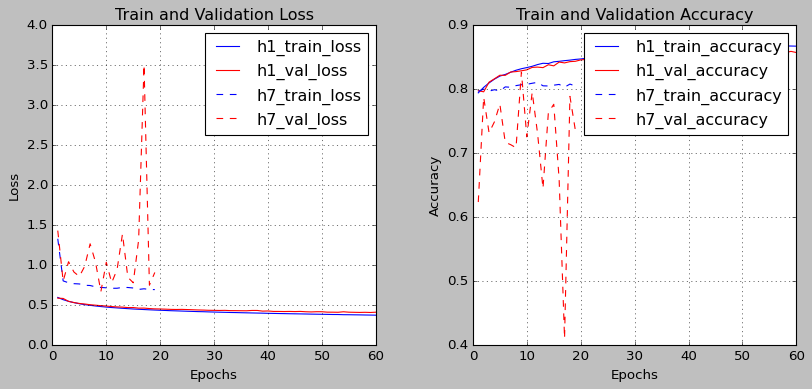

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8210 - loss: 0.6874


[0.6876670122146606, 0.8181999921798706]

In [ ]:
diff_history(history, history7)
model7.evaluate(x_test, y_test)